<a href="https://colab.research.google.com/github/arulperiyannagounder-collab/Training_Hands_on/blob/main/Handwriting_analysis_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow. keras import layers
from skleran.datasets import

In [ ]:
mnist=keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train,x_test=x_train/255.0,x_test/255.0




11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


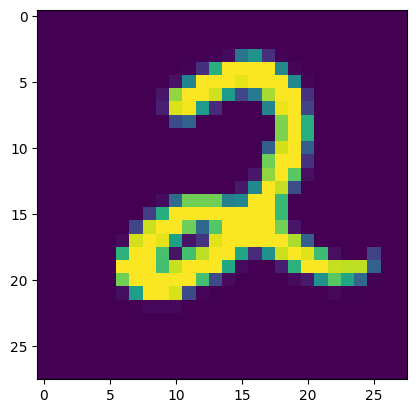

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[3333])

In [ ]:
model=keras.Sequential([

      keras.layers.Flatten(input_shape=(28,28,1)),
      keras.layers.Dense(128,activation='relu'),
      keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
h=model.fit(x_train,y_train,validation_split=0.1,epochs=10)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9230 - loss: 0.2713 - val_accuracy: 0.9655 - val_loss: 0.1294
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9650 - loss: 0.1199 - val_accuracy: 0.9693 - val_loss: 0.1038
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9759 - loss: 0.0807 - val_accuracy: 0.9765 - val_loss: 0.0749
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9815 - loss: 0.0607 - val_accuracy: 0.9772 - val_loss: 0.0821
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9857 - loss: 0.0456 - val_accuracy: 0.9788 - val_loss: 0.0773
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9886 - loss: 0.0360 - val_accuracy: 0.9778 - val_loss: 0.0792
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9912 - loss: 0.0286 - val_accuracy: 0.9792 - val_loss: 0.0765
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9930 - loss: 0.0231 -

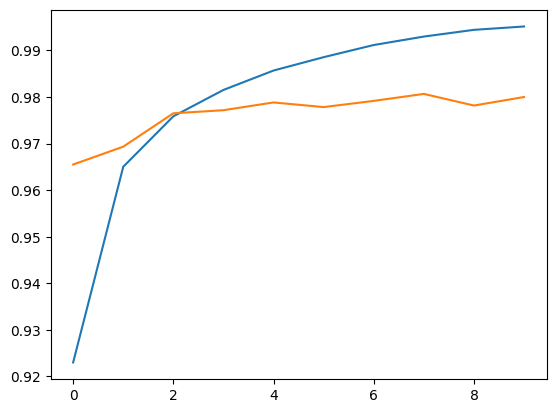

In [ ]:
plt.plot(h.history['accuracy'])
plt.plot(h.history['val_accuracy'])

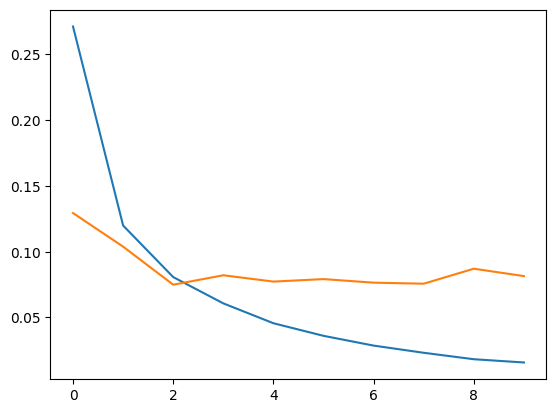

In [ ]:
plt.plot(h.history['loss'])
plt.plot(h.history['val_loss'])

In [ ]:
y_pred=model.predict(x_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred[9999]

array([4.8259237e-13, 3.4492973e-15, 1.4064923e-11, 3.1106578e-15,
       1.6015894e-08, 3.5289931e-12, 9.9999994e-01, 1.2161267e-15,
       6.9659453e-13, 3.3192403e-18], dtype=float32)

In [ ]:
import numpy as np
y_pred=np.argmax(y_pred,axis=1)
y_pred[9999]

np.int64(6)

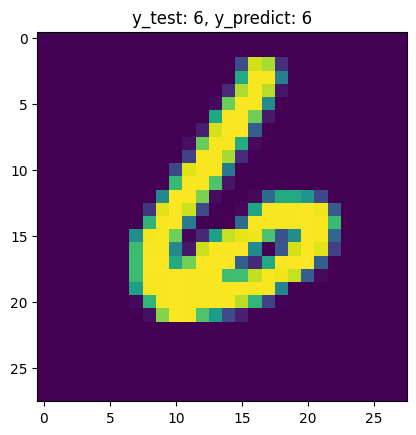

In [ ]:
import matplotlib.pyplot as plt
idx = 8888
plt.imshow(x_test[idx])
plt.title(f"y_test: {y_test[idx]}, y_predict: {y_pred[idx]}")
plt.show()

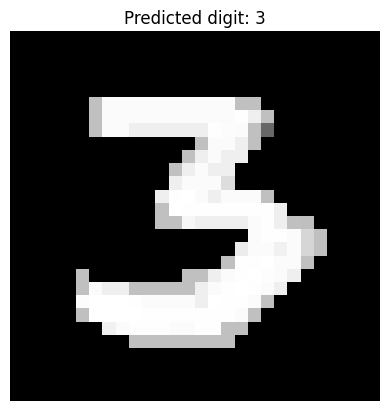

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt



img=cv2.imread('/content/drive/MyDrive/PLACEMENT AI/Collab/ANN/Screenshot 2026-06-04 110559.png')


img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_resized = 255-cv2.resize(img_gray, (28, 28))
img_normalized = (img_resized / 255.0).astype(np.float32)
img_final = np.expand_dims(img_normalized, axis=-1)
img_final = np.expand_dims(img_final, axis=0)
img_final_tf = tf.convert_to_tensor(img_final, dtype=tf.float32)
y_pred2 = model(img_final_tf, training=False)
predicted_digit = np.argmax(y_pred2)
plt.imshow(img_resized, cmap='gray')
plt.title(f"Predicted digit: {predicted_digit}")
plt.axis('off')
plt.show()

In [ ]:
model.save('ANNmodel.h5')